# Zomato Restaurant Analysis Using Pandas

In [2]:
# Import Required Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Load Dataset
df = pd.read_csv("../data/zomato.csv")

In [4]:
# Initial Dataset Exploration
df.head(5)

,url,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city)
0,https://www.zomato.com/bangalore/jalsa-banasha...,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1/5,775,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,"[('Rated 4.0', 'RATED\n A beautiful place to ...",[],Buffet,Banashankari
1,https://www.zomato.com/bangalore/spice-elephan...,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1/5,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,"[('Rated 4.0', 'RATED\n Had been here for din...",[],Buffet,Banashankari
2,https://www.zomato.com/SanchurroBangalore?cont...,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8/5,918,+91 9663487993,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800,"[('Rated 3.0', ""RATED\n Ambience is not that ...",[],Buffet,Banashankari
3,https://www.zomato.com/bangalore/addhuri-udupi...,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7/5,88,+91 9620009302,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300,"[('Rated 4.0', ""RATED\n Great food and proper...",[],Buffet,Banashankari
4,https://www.zomato.com/bangalore/grand-village...,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8/5,166,+91 8026612447\r\n+91 9901210005,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600,"[('Rated 4.0', 'RATED\n Very good restaurant ...",[],Buffet,Banashankari


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51717 entries, 0 to 51716
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   url                          51717 non-null  object
 1   address                      51717 non-null  object
 2   name                         51717 non-null  object
 3   online_order                 51717 non-null  object
 4   book_table                   51717 non-null  object
 5   rate                         43942 non-null  object
 6   votes                        51717 non-null  int64 
 7   phone                        50509 non-null  object
 8   location                     51696 non-null  object
 9   rest_type                    51490 non-null  object
 10  dish_liked                   23639 non-null  object
 11  cuisines                     51672 non-null  object
 12  approx_cost(for two people)  51371 non-null  object
 13  reviews_list                 51

In [6]:
# Missing Value Analysis
df.isna().sum()

url                                0
address                            0
name                               0
online_order                       0
book_table                         0
rate                            7775
votes                              0
phone                           1208
location                          21
rest_type                        227
dish_liked                     28078
cuisines                          45
approx_cost(for two people)      346
reviews_list                       0
menu_item                          0
listed_in(type)                    0
listed_in(city)                    0
dtype: int64

### ============================================================
### Data Cleaning
### ============================================================

In [7]:
# Remove dish_liked column due to excessive missing values
df.drop(columns=['dish_liked'],inplace=True)

In [8]:
df.columns

Index(['url', 'address', 'name', 'online_order', 'book_table', 'rate', 'votes',
       'phone', 'location', 'rest_type', 'cuisines',
       'approx_cost(for two people)', 'reviews_list', 'menu_item',
       'listed_in(type)', 'listed_in(city)'],
      dtype='object')

In [9]:
# Remove records where location is unavailable
df.dropna(subset=['location'],inplace=True)

In [10]:
# Remove records where cuisine information is unavailable
df.dropna(subset=['cuisines'],inplace=True)

In [11]:
# Check duplicate records
df.duplicated().sum()

0

In [12]:
# Remove missing values from cost column
df.dropna(subset=['approx_cost(for two people)'],inplace=True)

In [13]:
# Remove comma separator from cost values
df['approx_cost(for two people)'] = df['approx_cost(for two people)'].str.replace(',','')

In [14]:
# Convert cost column to integer datatype
df['approx_cost(for two people)'] = df['approx_cost(for two people)'].astype(int)

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 51352 entries, 0 to 51716
Data columns (total 16 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   url                          51352 non-null  object
 1   address                      51352 non-null  object
 2   name                         51352 non-null  object
 3   online_order                 51352 non-null  object
 4   book_table                   51352 non-null  object
 5   rate                         43682 non-null  object
 6   votes                        51352 non-null  int64 
 7   phone                        50481 non-null  object
 8   location                     51352 non-null  object
 9   rest_type                    51148 non-null  object
 10  cuisines                     51352 non-null  object
 11  approx_cost(for two people)  51352 non-null  int32 
 12  reviews_list                 51352 non-null  object
 13  menu_item                    51352 n

In [16]:
df.isna().sum()

url                               0
address                           0
name                              0
online_order                      0
book_table                        0
rate                           7670
votes                             0
phone                           871
location                          0
rest_type                       204
cuisines                          0
approx_cost(for two people)       0
reviews_list                      0
menu_item                         0
listed_in(type)                   0
listed_in(city)                   0
dtype: int64

In [17]:
# Remove missing values from rest_type column
df.dropna(subset=['rest_type'],inplace=True)

In [18]:
df.isna().sum()

url                               0
address                           0
name                              0
online_order                      0
book_table                        0
rate                           7615
votes                             0
phone                           869
location                          0
rest_type                         0
cuisines                          0
approx_cost(for two people)       0
reviews_list                      0
menu_item                         0
listed_in(type)                   0
listed_in(city)                   0
dtype: int64

## Most Popular Restaurant Types by Votes

In [19]:
df['votes'].head()

0    775
1    787
2    918
3     88
4    166
Name: votes, dtype: int64

In [20]:
# Total votes received by each restaurant type
Votes = df.groupby('rest_type')['votes'].sum().sort_values(ascending=False)
Votes.head(5)

rest_type
Casual Dining          4540798
Quick Bites            1474502
Cafe                   1438546
Casual Dining, Bar     1222084
Casual Dining, Cafe     527720
Name: votes, dtype: int64

In [21]:
Votes.reset_index().head(5)

,rest_type,votes
0,Casual Dining,4540798
1,Quick Bites,1474502
2,Cafe,1438546
3,"Casual Dining, Bar",1222084
4,"Casual Dining, Cafe",527720


In [22]:
Votess = Votes.reset_index().head(5)

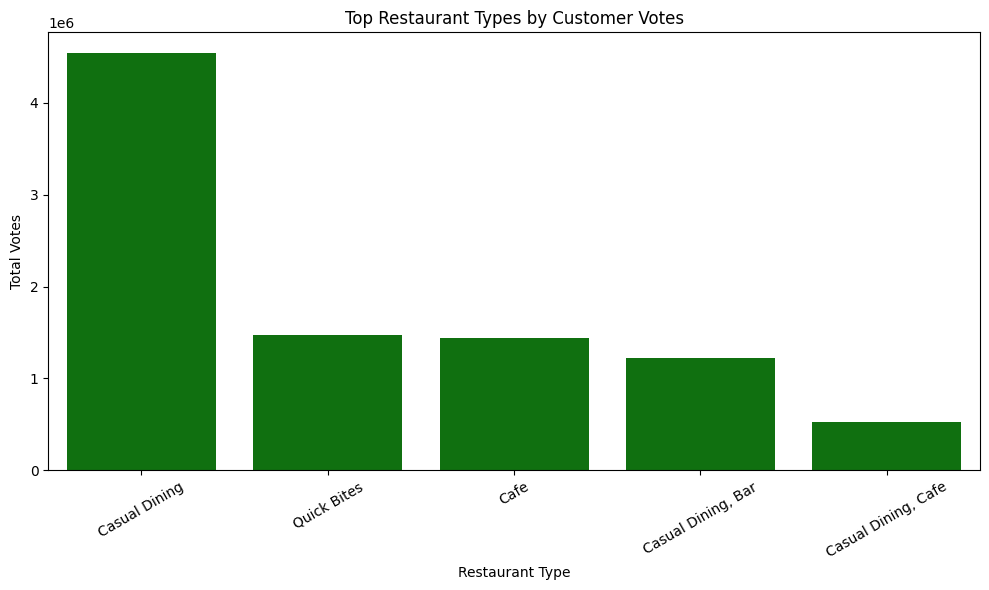

In [44]:
plt.figure(figsize=(10,6))

sns.barplot(
    x='rest_type',
    y='votes',
    data=Votess,
    color='green'
)

plt.title('Top Restaurant Types by Customer Votes')
plt.xlabel('Restaurant Type')
plt.ylabel('Total Votes')
plt.xticks(rotation=30)
plt.tight_layout()

plt.savefig(
    "../images/top_restaurant_types_by_votes.png",
    dpi=300,
    bbox_inches='tight'
)


plt.show()

### Insights
Casual Dining restaurants receive significantly higher customer engagement than other restaurant types, indicating strong customer preference and interaction within this segment.

## Average Cost Analysis by Restaurant Type

In [24]:
avg_cost_by_rest_type = (
    df.groupby('rest_type')['approx_cost(for two people)']
      .mean()
      .sort_values(ascending=False)
)

avg_cost_by_rest_type.head(10)

rest_type
Fine Dining, Bar             3002.500000
Fine Dining, Microbrewery    3000.000000
Fine Dining, Lounge          3000.000000
Fine Dining                  2707.514451
Bar, Lounge                  2450.000000
Club, Casual Dining          2400.000000
Club                         2145.945946
Lounge, Bar                  2027.777778
Lounge, Microbrewery         2000.000000
Bar, Quick Bites             2000.000000
Name: approx_cost(for two people), dtype: float64

In [25]:
top_expensive_rest_types = avg_cost_by_rest_type.reset_index().head(10)

In [26]:
top_expensive_rest_types.columns

Index(['rest_type', 'approx_cost(for two people)'], dtype='object')

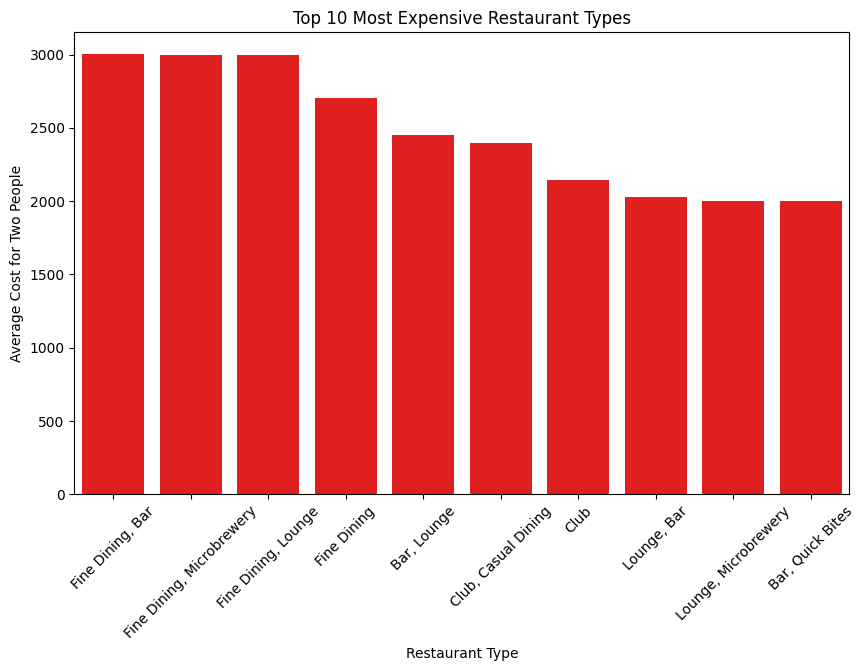

In [45]:
plt.figure(figsize=(10,6))

sns.barplot(
    x='rest_type',
    y='approx_cost(for two people)',
    data=top_expensive_rest_types,
    color='red'
)

plt.title('Top 10 Most Expensive Restaurant Types')
plt.xlabel('Restaurant Type')
plt.ylabel('Average Cost for Two People')
plt.xticks(rotation=45)
plt.savefig(
    "../images/top_10_most_expensive_restaurant_types.png",
    dpi=300,
    bbox_inches='tight'
)


plt.show()

### Insight

- Fine Dining restaurants have the highest average cost for two people.
- Premium dining experiences combined with bars, lounges, and microbreweries occupy the top positions.
- These restaurant categories target higher-income customer segments.

## Impact of Online Ordering on Customer Engagement

In [28]:
df['online_order'].head()

0    Yes
1    Yes
2    Yes
3     No
4     No
Name: online_order, dtype: object

In [29]:
# Calculate average votes based on online ordering availability

avg_votes_by_online_order = (
    df.groupby('online_order')['votes']
      .mean()
)

avg_votes_by_online_order

online_order
No     251.321495
Yes    308.013394
Name: votes, dtype: float64

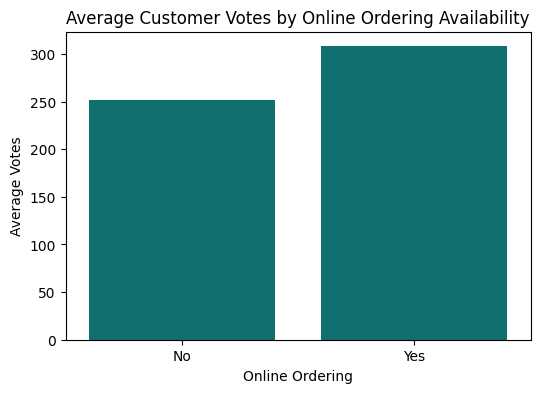

In [46]:
avg_votes_by_online_order = avg_votes_by_online_order.reset_index()

plt.figure(figsize=(6,4))

sns.barplot(
    x='online_order',
    y='votes',
    data=avg_votes_by_online_order,
    color='teal'
)

plt.title('Average Customer Votes by Online Ordering Availability')
plt.xlabel('Online Ordering')
plt.ylabel('Average Votes')
plt.savefig(
    "../images/online_ordering_vs_customer_votes.png",
    dpi=300,
    bbox_inches='tight'
)


plt.show()

### Insights
Restaurants that offer online ordering receive higher average customer engagement than restaurants that do not offer online ordering.

This suggests that online ordering may improve restaurant visibility and customer reach, leading to greater interaction and popularity.

In [31]:
# Remove missing values from rate column
df['rate'].unique()[:20]

array(['4.1/5', '3.8/5', '3.7/5', '3.6/5', '4.6/5', '4.0/5', '4.2/5',
       '3.9/5', '3.1/5', '3.0/5', '3.2/5', '3.3/5', '2.8/5', '4.4/5',
       '4.3/5', 'NEW', '2.9/5', '3.5/5', nan, '2.6/5'], dtype=object)

In [32]:
# Remove missing values from rate column
df.dropna(subset=['rate'],inplace=True)

In [33]:
# Removing new string in rate column
df = df[df['rate'] != 'NEW']

In [34]:
# Replace
df['rate'] = df['rate'].str.replace('/5','')

In [35]:
df['rate'].unique()

array(['4.1', '3.8', '3.7', '3.6', '4.6', '4.0', '4.2', '3.9', '3.1',
       '3.0', '3.2', '3.3', '2.8', '4.4', '4.3', '2.9', '3.5', '2.6',
       '3.8 ', '3.4', '4.5', '2.5', '2.7', '4.7', '2.4', '2.2', '2.3',
       '3.4 ', '-', '3.6 ', '4.8', '3.9 ', '4.2 ', '4.0 ', '4.1 ', '3.7 ',
       '3.1 ', '2.9 ', '3.3 ', '2.8 ', '3.5 ', '2.7 ', '2.5 ', '3.2 ',
       '2.6 ', '4.5 ', '4.3 ', '4.4 ', '4.9', '2.1', '2.0', '1.8', '4.6 ',
       '4.9 ', '3.0 ', '4.8 ', '2.3 ', '4.7 ', '2.4 ', '2.1 ', '2.2 ',
       '2.0 ', '1.8 '], dtype=object)

In [36]:
df = df[df['rate'] != '-']

In [37]:
# Change rate data type object to float
df['rate'] = df['rate'].astype(float)

In [38]:
df.isna().sum()

url                              0
address                          0
name                             0
online_order                     0
book_table                       0
rate                             0
votes                            0
phone                          576
location                         0
rest_type                        0
cuisines                         0
approx_cost(for two people)      0
reviews_list                     0
menu_item                        0
listed_in(type)                  0
listed_in(city)                  0
dtype: int64

In [39]:
# Calculate average rating by location

top_rated_locations = (
    df.groupby('location')['rate']
      .mean()
      .sort_values(ascending=False)
      .head(10)
)

top_rated_locations

location
Lavelle Road             4.141788
Koramangala 3rd Block    4.020419
St. Marks Road           4.017201
Koramangala 5th Block    4.006661
Church Street            3.992125
Sankey Road              3.965385
Koramangala 4th Block    3.918668
Cunningham Road          3.901053
Residency Road           3.864570
Koramangala 7th Block    3.852986
Name: rate, dtype: float64

In [40]:
# Convert Series into DataFrame

top_rated_locations_df = top_rated_locations.reset_index()

top_rated_locations_df.head()

,location,rate
0,Lavelle Road,4.141788
1,Koramangala 3rd Block,4.020419
2,St. Marks Road,4.017201
3,Koramangala 5th Block,4.006661
4,Church Street,3.992125


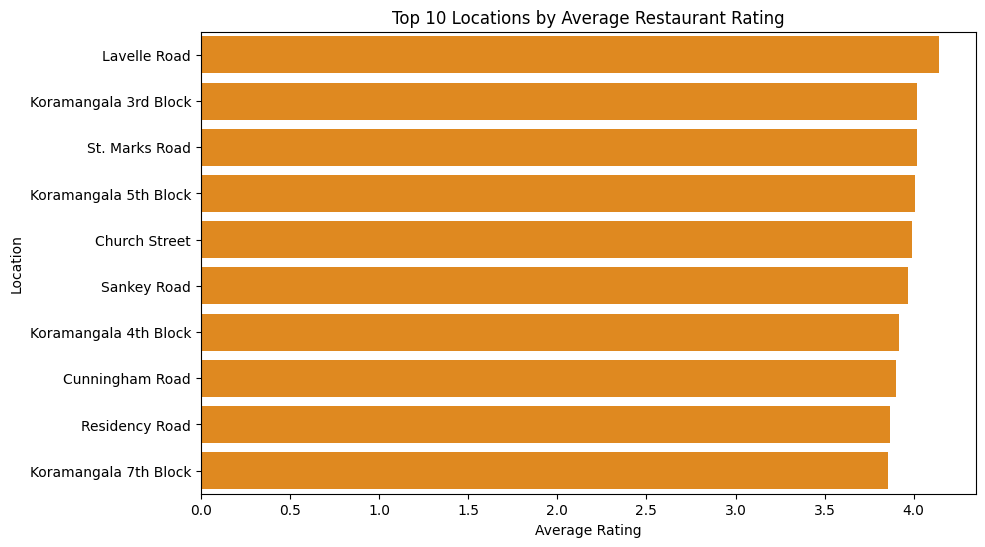

In [47]:
plt.figure(figsize=(10,6))

sns.barplot(
    x='rate',
    y='location',
    data=top_rated_locations_df,
    color='darkorange'
)

plt.title('Top 10 Locations by Average Restaurant Rating')
plt.xlabel('Average Rating')
plt.ylabel('Location')
plt.savefig(
    "../images/top_rated_locations.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

### Insights
Lavelle Road has the highest average restaurant rating among all locations in the dataset.


## Key Findings

- Casual Dining restaurants received the highest customer engagement.
- Restaurants offering online ordering attracted more customer interaction.
- Fine Dining categories had the highest average cost for two people.
- Lavelle Road and Koramangala contained some of the highest-rated restaurants.
- Premium restaurant categories generally maintained stronger ratings and customer engagement.

## Recommendations

- Promote online ordering to improve customer engagement.
- Focus marketing efforts on high-performing restaurant categories.
- Expand premium restaurant partnerships in highly rated locations.
- Encourage customer reviews and ratings to increase restaurant visibility.
- Use location-based strategies for restaurant growth and promotions.

## Conclusion

This analysis explored restaurant performance, customer engagement, pricing trends, and location-based insights using the Zomato dataset.

The findings indicate that restaurant type, online ordering availability, pricing strategy, and location all play important roles in influencing customer engagement and satisfaction.

These insights can help restaurant owners and food delivery platforms make more informed business decisions.